<a href="https://colab.research.google.com/github/roshansadath/COMP6721_Winter2023_GroupN/blob/main/Harvard%20Chest%20XRay/Inceptionv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import os, time, random, torch, warnings
import numpy as np
from PIL import Image
import torch.nn as nn
import seaborn as sns
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.models.inception import InceptionOutputs
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.simplefilter("ignore")
%run "/content/drive/MyDrive/Colab Notebooks/utils.ipynb"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
#data_path = "/content/drive/MyDrive/Colab Notebooks/Simple_Chest_XRay/"
#data_path = "/content/drive/MyDrive/Colab Notebooks/NIH_Chest_XRay/"
data_path = "/content/drive/MyDrive/Colab Notebooks/Harvard_Chest_XRay/"

sample_ratio = 0.4
batch_size = 96
num_epochs = 20

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
def data_sampling(indices):
  return torch.utils.data.sampler.SubsetRandomSampler(indices)

In [ ]:
def save_metrics(loss, accuracy, model):
  np.save("{}{}_train_loss.npy".format(data_path, model), loss)
  np.save("{}{}_train_accuracy.npy".format(data_path, model), accuracy)

**DATA PREPROCESSING**


In [ ]:
data_transforms = transforms.Compose([
  transforms.Resize((299, 299)),
  transforms.ToTensor(),
  transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

# Get dataset from folder and apply data transforms
# The original code assumed a 'data' subdirectory.
# If your images are directly in data_path, remove '/data'
# or replace it with the correct subdirectory if it's different.
dataset = datasets.ImageFolder(root = "{}".format(data_path), transform = data_transforms)

# Get a sample of the data randomly
num_samples = int(len(dataset) * sample_ratio)
indices = np.random.choice(range(len(dataset)), num_samples, replace = False)

# Split the data into training, test, and validation sets
train_size = int(0.7 * num_samples)
test_size = int(0.2 * num_samples)
val_size = num_samples - train_size - test_size

train_indices = indices[ : train_size]
test_indices = indices[train_size : train_size + test_size]
val_indices = indices[train_size + test_size : ]

samples = [data_sampling(i) for i in [train_indices, test_indices, val_indices]]

# Create data loaders for training, test, and validation sets
train_loader = DataLoader(dataset, batch_size = batch_size, sampler = samples[0])
test_loader = DataLoader(dataset, batch_size = batch_size, sampler = samples[1])
val_loader = DataLoader(dataset, batch_size = batch_size, sampler = samples[2])

 **DOWNLOAD RESNET18 MODEL AND TRAIN**


In [ ]:
# Define the Inceptionv3 model and set Pretraining to False to train model from scratch
model = torch.hub.load('pytorch/vision:v0.9.0', 'inception_v3', pretrained = False)
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))
model.to(device)

# Define loss function as CrossEntropy and optimizer as Adam Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

losses, accuracies, v_accuracies, v_losses = train_model(model, criterion, optimizer, "Inceptionv3", num_epochs)

Downloading: "https://github.com/pytorch/vision/zipball/v0.9.0" to /root/.cache/torch/hub/v0.9.0.zip
Epoch 1/20: 100%|██████████| 1/1 [00:02<00:00,  2.89s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 2/20: 100%|██████████| 1/1 [00:00<00:00,  6.42batch/s, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 3/20: 100%|██████████| 1/1 [00:00<00:00,  8.44batch/s, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


...

VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 19/20: 100%|██████████| 1/1 [00:00<00:00, 10.69batch/s, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  8.77batch/s, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



**SAVE MODEL PARAMETERS**

In [ ]:
torch.save(model.state_dict(), "{}inceptionv3.pth".format(data_path))

In [ ]:
def plot_model_curves(losses, accuracies, v_accuracies, v_losses):
  """Plots the accuracy and loss curves for training and validation.

  Args:
    losses: A list of training losses.
    accuracies: A list of training accuracies.
    v_accuracies: A list of validation accuracies.
    v_losses: A list of validation losses.
  """

  # Plot the loss curves
  plt.figure(figsize=(10, 5))
  plt.plot(losses, label='Training Loss')
  plt.plot(v_losses, label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  # Plot the accuracy curves
  plt.figure(figsize=(10, 5))
  plt.plot(accuracies, label='Training Accuracy')
  plt.plot(v_accuracies, label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

**EVALUATE MODEL ON VALIDATION AND TEST SET**

In [ ]:
def evaluate_model(model, dataloader, data_size, dtype, criterion, data_path, model_name):
    model.eval()
    _loss = 0
    _accuracy = 0
    _true, _pred = [], []

    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)
            _loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            _pred.extend(predicted.cpu().numpy())
            _true.extend(labels.cpu().numpy())

    # Check if data_size has any elements to avoid ZeroDivisionError
    if len(data_size) > 0:
        _loss /= len(data_size)
    else:
        _loss = 0  # or handle the case appropriately, e.g., raise an exception, print a warning

    _accuracy = accuracy_score(_true, _pred)
    _recall = recall_score(_true, _pred, average='macro')  # Handle zero division if needed
    _precision = precision_score(_true, _pred, average='macro', zero_division=0)  # Or set zero_division to 1
    _f1 = f1_score(_true, _pred, average='macro')  # Handle zero division if needed

    print('{} Loss: {:.4f}, Accuracy: {:.4f}, Recall: {:.4f}, Precision: {:.4f}, F1: {:.4f}'.format(dtype, _loss, _accuracy, _recall, _precision, _f1))

    # save_metrics(_loss, _accuracy, model_name) # You might need to check the save_metrics function as well

In [ ]:
!pip install --upgrade scikit-learn

import pandas as pd
from sklearn.manifold import TSNE
# ... your existing code ...

def plot_TSNE(train_loader, device, model):
  features = []
  labels = []

  with torch.no_grad():
      for data, target in train_loader:
          data, target = data.to(device), target.to(device)
          output = model(data)
          features.extend(output.cpu().numpy())
          labels.extend(target.cpu().numpy())

  features = np.array(features)
  labels = np.array(labels)

  # Calculate perplexity based on the number of samples
  perplexity = min(25, features.shape[0] - 1)  # Ensure perplexity < n_samples

  # Apply t-SNE with the calculated perplexity
  tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=600, n_iter=900)
  tsne_features = tsne.fit_transform(features)

  # ... rest of your plot_TSNE function ...

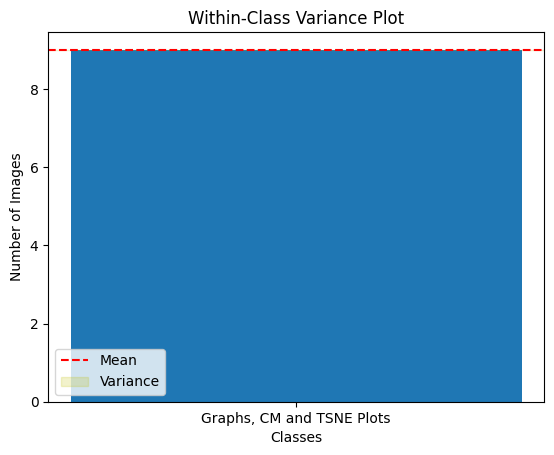

In [ ]:
#Plot the Within-Class Variance of the dataset
plot_within_class_variance(dataset)